Question — Logistic Regression: Student Placement Prediction
Objective :-
To implement Logistic Regression for predicting whether a student will be placed based on academic and skill-related features.
Problem Statement :-
A college wants to predict the placement status of students using the following attributes :-
CGPA,
IQ Score,
Aptitude Score,
Technical Skill Score,
Communication Skill Score
Target variable :-
1 → Placed
0 → Not Placed
Tasks :-
1. Create or use a dataset containing at least 100 student records.
2. Perform basic data preprocessing.
3. Separate the dataset into independent variables (X) and dependent variable (y).
4. Split the dataset into 80% training and 20% testing data.
5. Train a Logistic Regression model.
6. Predict the placement status of the test students.
7. Calculate :-
Accuracy
Precision
Recall
F1-Score
8. Generate and display the Confusion Matrix.
9. Plot the ROC Curve and calculate the AUC score.
10. Test the model with at least 5 new student records and predict their placement status.
Expected Output :-
The program should display:
● Dataset information
● Training and testing dataset size
● Predicted placement status
● Confusion Matrix
● Accuracy
● Precision
● Recall
● F1-Score
● ROC-AUC Score
● ROC Curve

First 5 rows of the dataset :- 
   CGPA  IQ_Score  Aptitude_Score  Technical_Skill_Score  \
0  6.87       111              71                     57   
1  9.75       118              94                     85   
2  8.66       128              43                     57   
3  7.99       131              94                     41   
4  5.78       140              50                     93   

   Communication_Skill_Score  Placement  
0                         81          0  
1                         41          1  
2                         65          1  
3                         56          1  
4                         79          0  

Dataset Information :- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       100 non-null    float64
 1   IQ_Score                   100 non-null    int64  
 2 

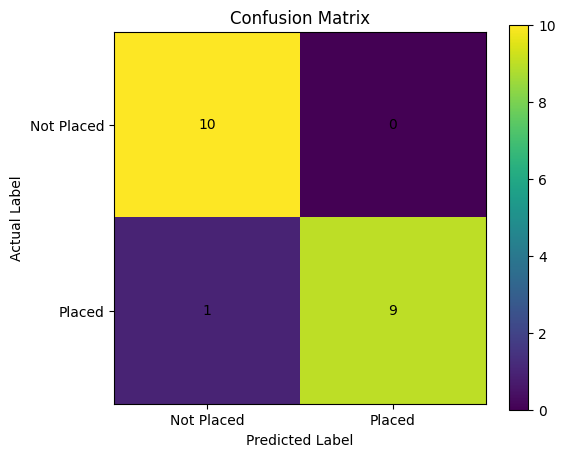


ROC-AUC Score :-  1.0



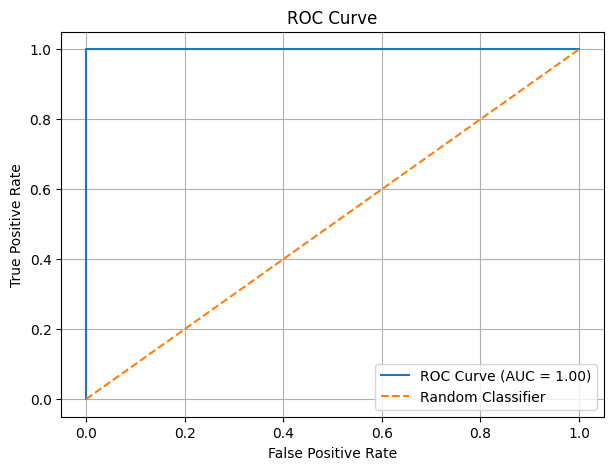


New Student Predictions :- 
Student 1: Placed (Probability of Placement = 1.00)
Student 2: Placed (Probability of Placement = 0.76)
Student 3: Not Placed (Probability of Placement = 0.00)
Student 4: Placed (Probability of Placement = 1.00)
Student 5: Not Placed (Probability of Placement = 0.00)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# 1. Create a dataset with 100 student records

np.random.seed(42)
data = {
    "CGPA": np.round(np.random.uniform(5.0, 10.0, 100), 2),
    "IQ_Score": np.random.randint(80, 141, 100),
    "Aptitude_Score": np.random.randint(40, 101, 100),
    "Technical_Skill_Score": np.random.randint(40, 101, 100),
    "Communication_Skill_Score": np.random.randint(40, 101, 100)
}
df = pd.DataFrame(data)

# Create Placement target variable

score = (
    df["CGPA"] * 10 + df["IQ_Score"] * 0.20 + df["Aptitude_Score"] * 0.30
    + df["Technical_Skill_Score"] * 0.30
    + df["Communication_Skill_Score"] * 0.20
)

# Median is used to divide students into placed/not placed
df["Placement"] = (score >= score.median()).astype(int)

# 2. Basic data preprocessing

print("First 5 rows of the dataset :- ")
print(df.head())

print("\nDataset Information :- ")
print(df.info())

print("\nMissing Values :- ")
print(df.isnull().sum())

# 3. Separate X and y

X = df[
    [
        "CGPA", "IQ_Score", "Aptitude_Score",
        "Technical_Skill_Score", "Communication_Skill_Score"
    ]
]

y = df["Placement"]

# 4. Split dataset into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining dataset size :- ", X_train.shape)
print("Testing dataset size :- ", X_test.shape)

# 5. Train Logistic Regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# 6. Predict placement status

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("\nPredicted Placement Status :- ")
print(y_pred)

# 7. Calculate performance metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance :- ")
print("Accuracy :- ", accuracy)
print("Precision :- ", precision)
print("Recall :- ", recall)
print("F1-Score :- ", f1)

print("\nClassification Report :- ")
print(classification_report(y_test, y_pred))

# 8. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix :- ")
print(cm)
print()

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.yticks([0, 1], ["Not Placed", "Placed"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# 9. ROC Curve and AUC Score

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

auc_score = roc_auc_score(y_test, y_probability)

print("\nROC-AUC Score :- ", auc_score)
print()

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

# 10. Test model with 5 new students

new_students = pd.DataFrame({
    "CGPA": [9.2, 7.5, 6.0, 8.7, 5.8],
    "IQ_Score": [130, 110, 85, 125, 90],
    "Aptitude_Score": [90, 75, 50, 88, 45],
    "Technical_Skill_Score": [92, 78, 55, 90, 50],
    "Communication_Skill_Score": [88, 72, 60, 85, 55]
})

new_predictions = model.predict(new_students)
new_probabilities = model.predict_proba(new_students)[:, 1]

print("\nNew Student Predictions :- ")

for i in range(len(new_students)):
    status = "Placed" if new_predictions[i] == 1 else "Not Placed"

    print(
        f"Student {i + 1}: {status} "
        f"(Probability of Placement = {new_probabilities[i]:.2f})"
    )